<div class="alert alert-success"><h1>Dropout Regularization of a Deep Learning Model in Python</h1></div>

Regularization is a set of techniques designed to reduce overfitting in machine learning models. Overfitting occurs when a model performs exceptionally well on the training data but fails to generalize to unseen data. This often happens when the model becomes overly complex and starts memorizing the noise or irrelevant details in the training data, instead of learning the underlying patterns.

Regularization works by introducing constraints or penalties to the training process, limiting the model’s ability to fit the training data too closely. By controlling the complexity of the model, regularization helps strike a balance between underfitting and overfitting, resulting in better generalization performance.

## Learning Objectives
By the end of this tutorial, you will:
+ Know how to apply Dropout regularization to a deep learning model.
+ Understand how to evaluate the impact of regularization on a deep learning model.


## Prerequisites
Before we begin, ensure you have:
+ Basic knowledge of Python programming (variables, functions, classes).
+ Familiarity with the fundamentals of how to build a deep learning model in Python using Keras.
+ A Python (version 3.x) environment with the `tensorflow`, `keras`, and `matplotlib` packages installed.

<div class="alert alert-success"><h2>1. Import and Preprocess the Data</h2></div>

We start by importing the data. For this tutorial, we'll use the **MNIST dataset**, a classic dataset in the machine learning community. It consists of 70,000 grayscale images of handwritten digits ranging from 0 to 9. Each image is 28 x 28 pixels, and the dataset is divided into 60,000 training images and 10,000 testing images. Our goal will be to develop a model that learns to correctly identify a handritten digit given the image.

In [1]:
from tensorflow import keras

keras.utils.set_random_seed(1234)
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Our deep learning model expects the images as a vector of size 784 (i.e. 28 $\times$ 28). So, let's flatten the images.

In [2]:
train_images = train_images.reshape(60000, 28 * 28)
test_images = test_images.reshape(10000, 28 * 28)

The model also expects the image pixel values scaled. Let's do that as well.

In [3]:
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

Finally, we also need to one-hot encode the image labels.

In [4]:
num_classes = 10
train_labels = keras.utils.to_categorical(train_labels, num_classes)
test_labels = keras.utils.to_categorical(test_labels, num_classes)

<div class="alert alert-success"><h2>2. Define the Baseline Model</h2></div>

The baseline model consists of an input layer with 784 nodes, two hidden layers with 512 and 128 nodes (respectively), and an output layer with 10 nodes.

In [5]:
from tensorflow.keras.layers import Input, Dense

model = keras.Sequential([
    Input(shape = (784,)),
    Dense(512, activation = 'relu'),
    Dense(128, activation = 'relu'),
    Dense(10, activation = 'softmax')
])

<div class="alert alert-success"><h2>3. Compile and Train the Baseline Model</h2></div>

Next, we compile the baseline model, ...

In [6]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

... train the model, ...

In [7]:
history = model.fit(
    train_images,
    train_labels,
    epochs = 15,
    batch_size = 128,
    validation_split = 0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8685 - loss: 0.4580 - val_accuracy: 0.9705 - val_loss: 0.0952
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9690 - loss: 0.1043 - val_accuracy: 0.9772 - val_loss: 0.0786
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9819 - loss: 0.0601 - val_accuracy: 0.9772 - val_loss: 0.0783
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9889 - loss: 0.0380 - val_accuracy: 0.9798 - val_loss: 0.0771
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9926 - loss: 0.0257 - val_accuracy: 0.9765 - val_loss: 0.0872
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9931 - loss: 0.0231 - val_accuracy: 0.9768 - val_loss: 0.0960
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9937 - loss: 0.0201 - val_accuracy: 0.9745 - val_loss: 0.1015
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9947 - loss: 0.0163 - val_a

... and plot the training and validation loss metrics.

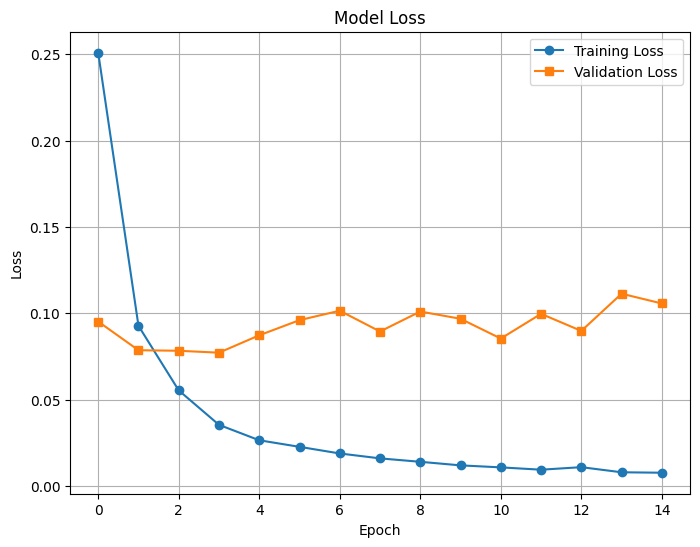

In [8]:
from matplotlib import pyplot as plt

plt.figure(figsize = (8, 6))
plt.plot(history.history['loss'], label = 'Training Loss', marker = 'o')
plt.plot(history.history['val_loss'], label = 'Validation Loss', marker = 's')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

A clear indicator of overfitting is the divergence in the training and validation loss metrics, which is visible in the training curves above.

<div class="alert alert-info"><b>Note:</b> To learn more about deep learning and how to build a deep learning model in Python using Keras, refer to  the LinkedIn Learning course titled <b>"Deep Learning with Python: Foundations"</b>.</div>

<div class="alert alert-success"><h2>4. Apply Dropout Regularization to the Model</h2></div>

Dropout Regularization randomly deactivates a fraction of neurons during training. This forces the network to learn robust features that do not depend too heavily on specific neurons.

To apply Dropout regularization to the baseline model, we add a `Dropout()` layer after each hidden layer of the network. The dropout percentage is set to 0.5, which means that 50\% of the neurons will be zeroed out during each forward pass.

In [10]:
from tensorflow.keras.layers import Dropout

model_dropout = keras.Sequential([
    Input(shape = (784,)),
    Dense(512, activation = 'relu'),
    Dropout(0.5),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(10, activation = 'softmax')
])

Next, we compile the regularized model,...

In [11]:
model_dropout.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

... train the regularized model, ...

In [12]:
history = model_dropout.fit(
    train_images,
    train_labels,
    epochs = 15,
    batch_size = 128,
    validation_split = 0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7488 - loss: 0.7832 - val_accuracy: 0.9620 - val_loss: 0.1315
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9331 - loss: 0.2274 - val_accuracy: 0.9717 - val_loss: 0.0966
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9494 - loss: 0.1693 - val_accuracy: 0.9747 - val_loss: 0.0862
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9587 - loss: 0.1387 - val_accuracy: 0.9763 - val_loss: 0.0817
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9635 - loss: 0.1249 - val_accuracy: 0.9785 - val_loss: 0.0758
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9679 - loss: 0.1075 - val_accuracy: 0.9780 - val_loss: 0.0759
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9707 - loss: 0.0996 - val_accuracy: 0.9827 - val_loss: 0.0639
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9725 - loss: 0.0892 - val_ac

... and plot the training and validation loss metrics.

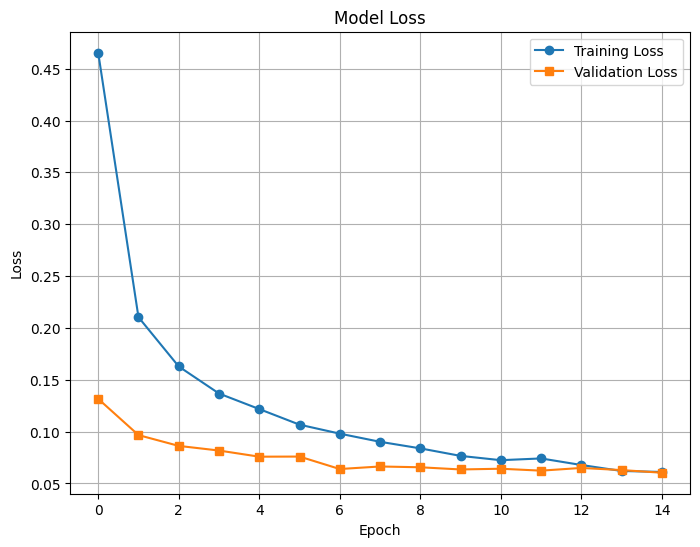

In [13]:
plt.figure(figsize = (8, 6))
plt.plot(history.history['loss'], label = 'Training Loss', marker = 'o')
plt.plot(history.history['val_loss'], label = 'Validation Loss', marker = 's')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

This time, we see that the training and validation loss metrics start off a bit divergent, but then start to converge as training continues. This indicates that dropout regularization is helping the model generalize better by preventing it from overfitting to the training data.

Early in training, the slight divergence occurs because dropout randomly deactivates neurons during forward passes, introducing variability in the model's behavior. However, as training progresses, the model adapts to these perturbations, learning more robust and generalized features that apply to both the training and validation data.

The convergence of training and validation loss demonstrates that the model is no longer overly dependent on specific neurons or subsets of features. Instead, it is leveraging a more diverse set of patterns to make predictions, which enhances its ability to generalize to unseen data. This behavior is a hallmark of dropout regularization's effectiveness, especially in deep neural networks prone to overfitting.